In [1]:
!pip install -Uqq fastbook
!pip install -Uqq kagglehub

In [17]:
from fastbook import *
import fastbook
fastbook.setup_book()

In [5]:
import kagglehub
import os

# Replace with the exact strings found inside your downloaded kaggle.json
os.environ["KAGGLE_USERNAME"] = "nickswekosky"
os.environ["KAGGLE_KEY"] = "e407816df0cb2205b1bb53770f87092b"

In [13]:
file_path = kagglehub.competition_download('titanic')

print("Path to competition files:", file_path)

Path to competition files: /root/.cache/kagglehub/competitions/titanic


In [215]:
from pathlib import Path
path = Path(file_path)
path.ls()

(#3) [Path('/root/.cache/kagglehub/competitions/titanic/test.csv'),Path('/root/.cache/kagglehub/competitions/titanic/gender_submission.csv'),Path('/root/.cache/kagglehub/competitions/titanic/train.csv')]

In [216]:
train_dt = pd.read_csv(path/"train.csv")

In [217]:
train_dt.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [218]:
modes = train_dt.mode().iloc[0]
modes

PassengerId                      1
Survived                       0.0
Pclass                         3.0
Name           Abbing, Mr. Anthony
Sex                           male
Age                           24.0
SibSp                          0.0
Parch                          0.0
Ticket                        1601
Fare                          8.05
Cabin                      B96 B98
Embarked                         S
Name: 0, dtype: object

In [219]:
train_dt.fillna(modes, inplace=True)

In [220]:
train_dt.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [221]:
train_dt.describe(include=[np.number])

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,28.566970,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.199572,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,24.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


<AxesSubplot:>

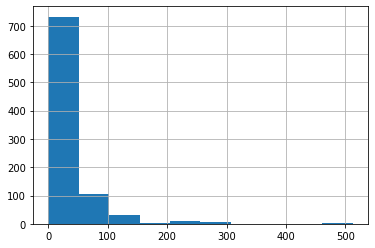

In [222]:
train_dt["Fare"].hist()

In [223]:
train_dt["LogFare"] = np.log(train_dt["Fare"] + 1)

<AxesSubplot:>

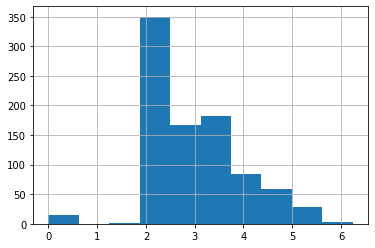

In [224]:
train_dt["LogFare"].hist()

In [225]:
train_dt.describe(include=[object])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,891,891
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,691,646


In [226]:
train_dt = pd.get_dummies(train_dt, columns=["Sex", "Pclass", "Embarked"])
train_dt.columns

Index(['PassengerId', 'Survived', 'Name', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Cabin', 'LogFare', 'Sex_female', 'Sex_male', 'Pclass_1',
       'Pclass_2', 'Pclass_3', 'Embarked_C', 'Embarked_Q', 'Embarked_S'],
      dtype='object')

In [227]:
added_cols = ['Sex_female', 'Sex_male', 'Pclass_1',
       'Pclass_2', 'Pclass_3', 'Embarked_C', 'Embarked_Q', 'Embarked_S']
train_dt[added_cols].head()

,Sex_female,Sex_male,Pclass_1,Pclass_2,Pclass_3,Embarked_C,Embarked_Q,Embarked_S
0,0,1,0,0,1,0,0,1
1,1,0,1,0,0,1,0,0
2,1,0,0,0,1,0,0,1
3,1,0,1,0,0,0,0,1
4,0,1,0,0,1,0,0,1


In [228]:
t_dep = tensor(train_dt.Survived)

In [229]:
indep_cols = ['Age', 'SibSp', 'Parch', 'LogFare'] + added_cols
t_indep = tensor(train_dt[indep_cols].values, dtype=torch.float)
t_indep.shape

torch.Size([891, 12])

## Setting up a linear model¶

In [230]:
torch.manual_seed(442)

n_coeff = t_indep.shape[1]
coeffs = torch.rand(n_coeff)-0.5
coeffs

tensor([-0.4629,  0.1386,  0.2409, -0.2262, -0.2632, -0.3147,  0.4876,  0.3136,  0.2799, -0.4392,  0.2103,  0.3625])

In [231]:
t_indep*coeffs

tensor([[-10.1838,   0.1386,   0.0000,  ...,  -0.0000,   0.0000,   0.3625],
        [-17.5902,   0.1386,   0.0000,  ...,  -0.4392,   0.0000,   0.0000],
        [-12.0354,   0.0000,   0.0000,  ...,  -0.0000,   0.0000,   0.3625],
        ...,
        [-11.1096,   0.1386,   0.4818,  ...,  -0.0000,   0.0000,   0.3625],
        [-12.0354,   0.0000,   0.0000,  ...,  -0.4392,   0.0000,   0.0000],
        [-14.8128,   0.0000,   0.0000,  ...,  -0.0000,   0.2103,   0.0000]])

In [232]:
vals, indices = t_indep.max(dim=0)
t_indep = t_indep / vals

In [234]:
t_indep*coeffs

tensor([[-0.1273,  0.0173,  0.0000,  ..., -0.0000,  0.0000,  0.3625],
        [-0.2199,  0.0173,  0.0000,  ..., -0.4392,  0.0000,  0.0000],
        [-0.1504,  0.0000,  0.0000,  ..., -0.0000,  0.0000,  0.3625],
        ...,
        [-0.1389,  0.0173,  0.0803,  ..., -0.0000,  0.0000,  0.3625],
        [-0.1504,  0.0000,  0.0000,  ..., -0.4392,  0.0000,  0.0000],
        [-0.1852,  0.0000,  0.0000,  ..., -0.0000,  0.2103,  0.0000]])

In [235]:
preds = (t_indep*coeffs).sum(axis=1)
preds[:10]

tensor([ 0.1412, -0.5725,  0.1494,  0.2571,  0.0453, -0.0448,  0.0792,  0.2961,  0.2128, -0.5770])

In [236]:
loss = torch.abs(preds-t_dep).mean()
loss

tensor(0.5200)

In [237]:
def calc_preds(coeffs, t_indep): return (t_indep*coeffs).sum(axis=1)
def calc_loss(coeffs, t_indep, t_dep): return torch.abs(calc_preds(coeffs, t_indep)-t_dep).mean()

## Doing a gradient step

In [238]:
coeffs.requires_grad_()

tensor([-0.4629,  0.1386,  0.2409, -0.2262, -0.2632, -0.3147,  0.4876,  0.3136,  0.2799, -0.4392,  0.2103,  0.3625], requires_grad=True)

In [239]:
loss = calc_loss(coeffs, t_indep, t_dep)
loss

tensor(0.5200, grad_fn=<MeanBackward0>)

In [240]:
loss.backward()

In [241]:

loss = calc_loss(coeffs, t_indep, t_dep)
loss.backward()

In [242]:
lr = 0.1
with torch.no_grad():
    coeffs.sub_(coeffs.grad * lr)
    coeffs.grad.zero_()
    print(calc_loss(coeffs, t_indep, t_dep))

tensor(0.4922)


## Training a linear model

In [243]:
from fastai.data.transforms import RandomSplitter
trn_split,val_split=RandomSplitter(seed=42)(train_dt)

In [244]:
trn_indep, val_indep = t_indep[trn_split], t_indep[val_split]
trn_dep, val_dep = t_dep[trn_split], t_dep[val_split]
len(trn_indep), len(val_indep)

(713, 178)

In [245]:
def update_coeffs(coeffs, lr):
    coeffs.sub_(coeffs.grad * lr)
    coeffs.grad.zero_()

def one_epoch(coeffs, lr):
    loss = calc_loss(coeffs, trn_indep, trn_dep)
    loss.backward()
    with torch.no_grad(): update_coeffs(coeffs, lr)
    print(f"{loss:.3f}", end="; ")

def init_coeffs():
    return (torch.rand(n_coeff) - 0.5).requires_grad_()

In [246]:
def train_model(epochs=30, lr=0.01):
    torch.manual_seed(442)
    coeffs = init_coeffs()
    for i in range(epochs): one_epoch(coeffs, lr)
    return coeffs

In [247]:
coeffs = train_model(epochs=18, lr=0.2)

0.518; 0.491; 0.468; 0.445; 0.422; 0.400; 0.378; 0.358; 0.340; 0.327; 0.315; 0.306; 0.308; 0.311; 0.311; 0.292; 0.296; 0.287; 

In [248]:
def show_coeffs(): return dict(zip(indep_cols, coeffs.requires_grad_(False)))
show_coeffs()

{'Age': tensor(-0.2581),
 'SibSp': tensor(0.0894),
 'Parch': tensor(0.2346),
 'LogFare': tensor(0.0275),
 'Sex_female': tensor(0.2574),
 'Sex_male': tensor(-0.4129),
 'Pclass_1': tensor(0.7098),
 'Pclass_2': tensor(0.4246),
 'Pclass_3': tensor(0.3691),
 'Embarked_C': tensor(0.0955),
 'Embarked_Q': tensor(0.2490),
 'Embarked_S': tensor(0.2116)}

## Measuring accuracy

In [249]:
def acc(coeffs): return (val_dep.bool()==(calc_preds(coeffs, val_indep)>0.5)).float().mean()
acc(coeffs)

tensor(0.7978)

## Sigmoid

In [250]:
def calc_preds(coeffs, indeps): return torch.sigmoid((indeps*coeffs).sum(axis=1))

In [251]:
acc(coeffs)

tensor(0.4213)

In [252]:
coeffs = train_model(lr=100)

0.503; 0.326; 0.294; 0.207; 0.201; 0.199; 0.198; 0.197; 0.196; 0.196; 0.196; 0.195; 0.195; 0.195; 0.195; 0.195; 0.195; 0.195; 0.194; 0.194; 0.194; 0.194; 0.194; 0.194; 0.194; 0.194; 0.194; 0.194; 0.194; 0.194; 

In [253]:
acc(coeffs)

tensor(0.8258)

In [254]:
show_coeffs()


{'Age': tensor(-1.5097),
 'SibSp': tensor(-1.1564),
 'Parch': tensor(-0.4253),
 'LogFare': tensor(0.2456),
 'Sex_female': tensor(8.4482),
 'Sex_male': tensor(-10.3873),
 'Pclass_1': tensor(3.8377),
 'Pclass_2': tensor(2.1304),
 'Pclass_3': tensor(-6.2481),
 'Embarked_C': tensor(1.4744),
 'Embarked_Q': tensor(2.1067),
 'Embarked_S': tensor(-4.8086)}

## Submitting to Kaggle¶


In [255]:
tst_df = pd.read_csv(path/'test.csv')
tst_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [256]:
tst_df['Fare'] = tst_df.Fare.fillna(0)

In [257]:
vals

tensor([80.0000,  8.0000,  6.0000,  6.2409,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000])

In [258]:
tst_df.fillna(modes, inplace=True)
tst_df['LogFare'] = np.log(tst_df['Fare']+1)
tst_df = pd.get_dummies(tst_df, columns=["Sex","Pclass","Embarked"])

tst_indep = tensor(tst_df[indep_cols].values, dtype=torch.float)
tst_indep = tst_indep / vals

In [259]:
tst_df['Survived'] = (calc_preds(tst_indep, coeffs)>0.5).int()

In [260]:
sub_df = tst_df[['PassengerId','Survived']]
sub_df.to_csv('sub.csv', index=False)

In [261]:
!head sub.csv

PassengerId,Survived
892,0
893,0
894,0
895,0
896,0
897,0
898,1
899,0
900,1


## Matrix multiplication

In [262]:
def calc_preds(coeffs, indeps): return torch.sigmoid(indeps@coeffs)

In [263]:
def init_coeffs(): return (torch.rand(n_coeff, 1)*0.1).requires_grad_()

In [264]:
trn_dep = trn_dep[:,None]
val_dep = val_dep[:,None]

In [265]:
coeffs = train_model(lr=100)

0.512; 0.323; 0.290; 0.205; 0.200; 0.198; 0.197; 0.197; 0.196; 0.196; 0.196; 0.195; 0.195; 0.195; 0.195; 0.195; 0.195; 0.194; 0.194; 0.194; 0.194; 0.194; 0.194; 0.194; 0.194; 0.194; 0.194; 0.194; 0.194; 0.194; 

In [266]:
acc(coeffs)

tensor(0.8258)

## A neural network¶